# Set-Up

In [7]:
# Import packages
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import os, sys, json, time, glob, warnings
from torchmetrics.functional import structural_similarity_index_measure as ssim


# Add parent directory to sys.path for module imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import modules
from src.data.dataset import LidarS2Dataset
from src.data.processing import compute_s2_mean_std_multi
from src.model.unet import ConditionalUNet
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddpm, p_sample_loop_ddim, p_sample_loop_plms
from src.utils.metrics import compute_topographic_rmse, normalize_batch
import rasterio
from scripts.main import run_reconstruction_evaluation
from src.data.dataset import LidarS2Dataset

# Ignore warnings
warnings.filterwarnings("ignore")

# Testing

In [6]:
# Config 

CKPT_PATH = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/models/final_improved_baseline_k1_att_best.pth"         
TEST_S2_DIR = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/s2_patches_tuk"       
TEST_LIDAR_DIR = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/tuk_lidar_patches" 
OUT_DIR = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/figures/test"

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = torch.load(CKPT_PATH, map_location=device)
config = ckpt["config"]  # original training config

# Override paths for test data
config["data"]["s2_dir"]   = TEST_S2_DIR
config["data"]["lidar_dir"] = TEST_LIDAR_DIR
config["logging"]["output_dir"] = OUT_DIR
config["system"]["device"] = device

In [8]:
# Reuse training S2 stats for normalization to avoid data leakage

stats = torch.load(os.path.join("/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/s2_patches", "s2_stats_24.pt"))
s2_means, s2_stds = stats["mean"], stats["std"]

# Create test dataset 

test_dataset = LidarS2Dataset(
    lidar_dir=TEST_LIDAR_DIR,
    s2_dir=TEST_S2_DIR,
    s2_means=s2_means,
    s2_stds=s2_stds,
    context_k=config["training"]["context_k"],
    randomize_context=False,
    augment=False,
    debug=False,
    split="val"   # important: eval mode
)

Prepared 396 matched LiDAR↔S2 groups (k=1).


In [12]:
# Load in trained model

model = ConditionalUNet(
    in_channels=1,
    cond_channels=4 * config["training"]["context_k"],
    attr_dim=8 * config["training"]["context_k"],
    base_channels=config["model"]["base_channels"],
    embed_dim=config["model"]["embed_dim"],
    unet_depth=config["model"]["unet_depth"],
    attention_variant=config["model"]["attention_variant"]
).to(device)
model.load_state_dict(ckpt["model_state_dict"])

# Load in diffusion scheduler from trained model
if config["training"]["noise_schedule"] == "linear":
    scheduler = LinearDiffusionScheduler(config["training"]["timesteps"], device=device)
else:
    scheduler = CosineDiffusionScheduler(config["training"]["timesteps"], device=device)


In [13]:
# Reconstruction evaluation function

def run_reconstruction_evaluation(model, val_dataset, config, scheduler=None):
    """
    Run reconstruction evaluation with S2 selection and error map visualization.
    """
    print("\n" + "="*60)
    print("RUNNING RECONSTRUCTION EVALUATION")
    print("="*60)

    # Set split for augmentation control
    val_dataset.split = "val"

    # Define output directories
    output_dir = config["logging"]["output_dir"]
    stats_dir = os.path.join(output_dir, "reconstruction_statistics")
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(stats_dir, exist_ok=True)
    
    # Set model to eval
    model.eval()
    
    # Access hand-picked validation sets by ID
    eval_pids = ["00010", "00025", "00050", "00060", "00100", "00150", "00008", "00009"]

    # Find the indices of these patches in the validation dataset
    eval_indices = [i for i, sample in enumerate(val_dataset.samples) if sample['tile_id'] in eval_pids]

    # Handle the case where not all patches are found
    if len(eval_indices) != len(eval_pids):
        print(f"Warning: Found {len(eval_indices)} out of 8 requested evaluation patches. Continuing with found patches.")
    
    # Create a Subset of the validation dataset using the found indices
    eval_subset = Subset(val_dataset, eval_indices)

    # Create eval loader
    eval_loader = DataLoader(eval_subset, batch_size=len(eval_subset), shuffle=False)
    
    # Access the single batch from the evaluation loader
    batch = next(iter(eval_loader))
    s2 = batch["s2"].to(config["system"]["device"])
    lidar = batch["lidar"].to(config["system"]["device"])
    attrs = batch["attrs"].to(config["system"]["device"])
    mask = batch["mask"].to(config["system"]["device"])
    chosen_ids_batch = batch["chosen_ids"]
    tile_ids_batch = batch["tile_id"] 

    # Get batch dimensions and context information
    B = lidar.size(0)
    context_k = config["training"]["context_k"]
    run_name = config["logging"]["run_name"]

    # Get sampling methods
    all_samplers = {
        "ddpm": lambda m, s, c, a, d: p_sample_loop_ddpm(m, scheduler, s, c, a, d) if scheduler else None,
        "ddim": lambda m, s, c, a, d: p_sample_loop_ddim(m, scheduler, s, c, a, d) if scheduler else None,
        "plms": lambda m, s, c, a, d: p_sample_loop_plms(m, scheduler, s, c, a, d) if scheduler else None,
    }
    requested_methods = config["evaluation"]["sampling_methods"]
    p_samplers = {m: all_samplers[m] for m in requested_methods if m in all_samplers}
    if not p_samplers:
        print("No valid samplers available")
        return

    # Determine which sentinel-2 patches were used to condition the model
    used_patch_ids = chosen_ids_batch

    # Iterate over each sampling method
    for sampler_name, sampler_func in p_samplers.items():
        print(f"\nSampling method: {sampler_name}")

        # Sample from the model
        with torch.no_grad():
            torch.cuda.synchronize()
            start_time = time.perf_counter()
            pred = sampler_func(model, lidar.shape, s2, attrs, config["system"]["device"])
            torch.cuda.synchronize()
            end_time = time.perf_counter()
            sampling_time = end_time - start_time


            # Move tensors to CPU
            gt = lidar.cpu()
            pred = pred.cpu()

            # Calculate and log core reconstruction metrics for the entire batch
            mae_tile = F.l1_loss(pred, gt, reduction='none').mean(dim=(1, 2, 3)).tolist()
            rmse_tile = ((pred - gt) ** 2).mean(dim=(1, 2, 3)).sqrt().tolist()
            ssim_tile = [ssim(normalize_batch(pred[i:i+1]), normalize_batch(gt[i:i+1]), data_range=1.0).item() for i in range(B)]
            topo_tile = [compute_topographic_rmse(gt[i:i+1], pred[i:i+1]).item() for i in range(B)]
            rough_tile = [abs(torch.std(gt[i]) - torch.std(pred[i])).item() for i in range(B)]

            # Calculate averages for logging
            mae = float(np.mean(mae_tile))
            rmse = float(np.mean(rmse_tile))
            ssim_avg = float(np.mean(ssim_tile))
            topo_avg = float(np.mean(topo_tile))
            rough_avg = float(np.mean(rough_tile))

            # Save reconstruction statistics for each sample
            for i in range(B):
                tile_id = tile_ids_batch[i]
                reco_stats = {
                    "tile_id": tile_id,
                    "mae": mae_tile[i],
                    "rmse": rmse_tile[i],
                    "ssim": ssim_tile[i],
                    "topographic_rmse": topo_tile[i],
                    "roughness": rough_tile[i],
                    "gt_min_val": float(gt[i].min()),
                    "gt_max_val": float(gt[i].max()),
                    "gt_mean_val": float(gt[i].mean()),
                    "gt_std_val": float(gt[i].std()),
                    "pred_min_val": float(pred[i].min()),
                    "pred_max_val": float(pred[i].max()),
                    "pred_mean_val": float(pred[i].mean()),
                    "pred_std_val": float(pred[i].std()),
                    "gt_mode_val": float(torch.mode(gt[i].flatten().to(torch.float32))[0]),
                    "pred_mode_val": float(torch.mode(pred[i].flatten().to(torch.float32))[0]),
                }
                
                debug_flag = "_debug_" if config["system"]["debug"] else ""
                #stats_path = os.path.join(stats_dir, f"{tile_id}{debug_flag}{run_name}_{sampler_name}_stats.json")
                #with open(stats_path, "w") as f:
                    #json.dump(reco_stats, f, indent=4)
                #print(f"Saved stats for tile {tile_id} to {stats_path}")

            # Visualization normalization + error calculations
            gt_norm = normalize_batch(gt)
            pred_norm = normalize_batch(pred)
            abs_error = (gt - pred).abs()
            err_max = abs_error.amax(dim=(1,2,3), keepdim=True)
            err_norm = abs_error / (err_max + 1e-8)

            # Repeat grayscale GT, Pred, and Error tensors to have 3 channels for visualization
            gt_rgb = gt_norm.repeat(1, 3, 1, 1)
            pred_rgb = pred_norm.repeat(1, 3, 1, 1)
            err_rgb = err_norm.repeat(1, 3, 1, 1)

            # Rebuild the full S2 RGB stacks for visualization
            s2_processed_selected = []
            for i in range(B):
                tile_id = tile_ids_batch[i]
                s2_group_dir = os.path.join(val_dataset.s2_dir, f"s2_patch_{tile_id}")
                
                # Retrieve the specific indices used for conditioning for this sample
                chosen_ids = chosen_ids_batch[i].tolist()
                
                processed_sample = []
                for t_id in chosen_ids:
                    s2_path = os.path.join(s2_group_dir, f"t{t_id}.tif")
                    with rasterio.open(s2_path) as src:
                        arr = torch.from_numpy(src.read()[:4].astype(np.float32))
                    
                    # Get RGB for visualization
                    rgb = arr[[0, 1, 2], :, :]
                    rgb = normalize_batch(rgb.unsqueeze(0)).squeeze(0)
                    rgb = F.interpolate(rgb.unsqueeze(0), size=gt.shape[-2:], mode="bilinear", align_corners=False).squeeze(0)
                    processed_sample.append(rgb)
                s2_processed_selected.append(processed_sample)
            
            # Create visualization plot
            tiles = []
            for i in range(B):
                # Stack only the USED S2 times, then GT, Pred, Error
                rows = [p for p in s2_processed_selected[i]] + [gt_rgb[i], pred_rgb[i], err_rgb[i]]
                tile = torch.cat(rows, dim=1)
                tiles.append(tile)

            full_image = torch.cat(tiles, dim=2)
            img_np = full_image.permute(1, 2, 0).numpy()

            # Adjust the figure height based on the number of S2 patches
            fig_h = (context_k * 4) + 12
            fig, ax = plt.subplots(figsize=(42, fig_h))
            ax.axis("off")
            ax.imshow(img_np)

            # Adjust the row labels to only show the chosen S2 patches
            row_labels = [f"S2 t{t}" for t in chosen_ids_batch[0].tolist()] + ["GT", "Pred", "|Error|"]
            row_height = img_np.shape[0] // len(row_labels)
            for r, label in enumerate(row_labels):
                y = r * row_height + row_height // 2
                ax.text(-10, y, label, ha="right", va="center", fontsize=13, fontweight='bold',
                        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))
            
            tile_width = img_np.shape[1] // B
            for i in range(B):
                x = i * tile_width + 5
                metrics = (f"MAE: {mae_tile[i]:.3f}\n"
                           f"RMSE: {rmse_tile[i]:.3f}\n"
                           f"SSIM: {ssim_tile[i]:.3f}\n"
                           f"Topo: {topo_tile[i]:.3f}\n"
                           f"Rough: {rough_tile[i]:.3f}")
                ax.text(x, img_np.shape[0] + 10, metrics, ha='left', va='top',
                        fontsize=12, bbox=dict(facecolor='white', alpha=0.85, boxstyle='round'))
            
            footer = (f"Mean → MAE: {mae:.3f} | RMSE: {rmse:.3f} | SSIM: {ssim_avg:.3f} | Topo RMSE: {topo_avg:.3f} | "
                      f"Roughness: {rough_avg:.3f}")
            ax.text(img_np.shape[1] // 2, img_np.shape[0] + 120, footer,
                    ha='center', fontsize=16, weight='bold', color='darkblue')

            plt.tight_layout()
            #out_name = config["logging"]["wandb_name"] or config["logging"]["run_name"]
            #out_path = os.path.join(config["logging"]["output_dir"], f"{out_name}_{sampler_name}_vis.png")
            #fig.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.show()

            #print(f"Saved visualization to {out_path}")


RUNNING RECONSTRUCTION EVALUATION

Sampling method: plms


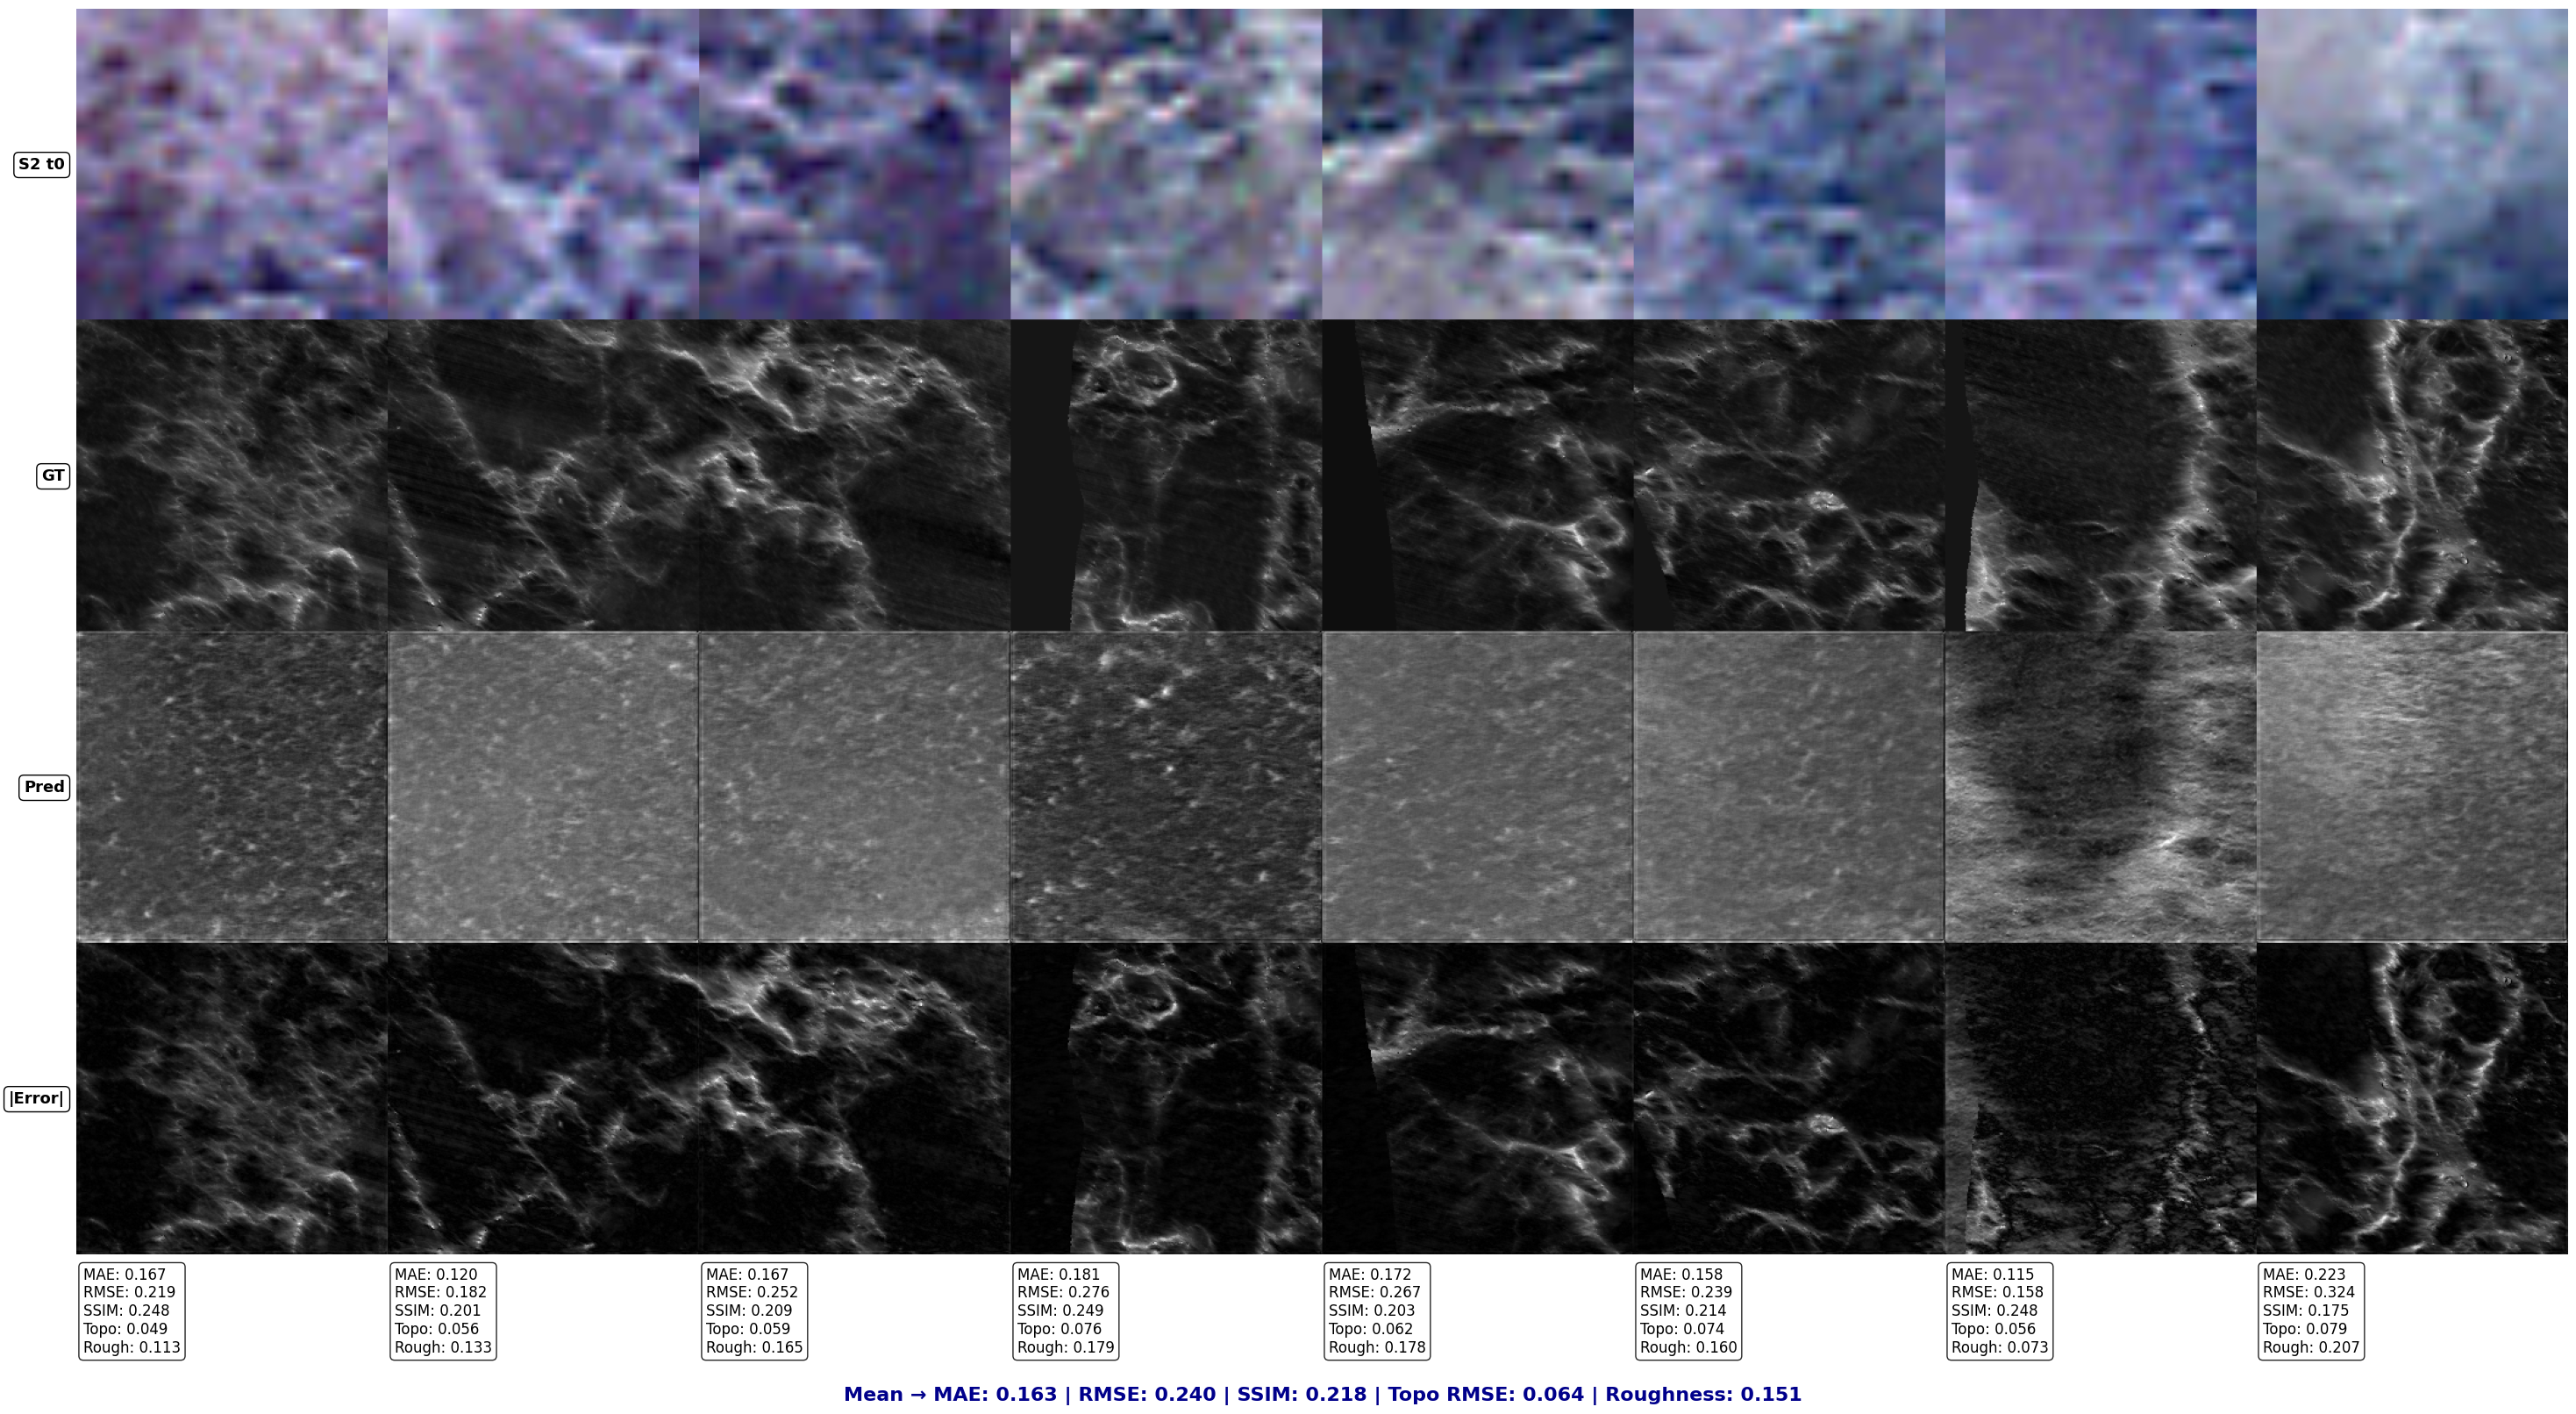

In [ ]:
# Run evaluation on sample batch

run_reconstruction_evaluation(model, test_dataset, config, scheduler)

# Additional Data Inspections

In [ ]:
# Inspect a sample Tuk Sentinel-2 patch 

p = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/s2_patches_tuk/s2_patch_00000/t0.tif"
with rasterio.open(p) as src:
    print(src.count, src.dtypes, src.descriptions) 
    a = src.read()[:4]
print("min/max per band:", [(float(a[i].min()), float(a[i].max())) for i in range(4)])


4 ('uint16', 'uint16', 'uint16', 'uint16') (None, None, None, None)
min/max per band: [(9459.0, 10323.0), (9349.0, 10288.0), (9435.0, 10295.0), (9440.0, 10144.0)]


In [ ]:
# Inspect a sample Pond Inlet Sentinel-2 patch 

p = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/s2_patches/s2_patch_00000/t0.tif"
with rasterio.open(p) as src:
    print(src.count, src.dtypes, src.descriptions)  # band names if present
    a = src.read()[:4]
print("min/max per band:", [(float(a[i].min()), float(a[i].max())) for i in range(4)])

4 ('uint16', 'uint16', 'uint16', 'uint16') (None, None, None, None)
min/max per band: [(10190.0, 10803.0), (10222.0, 10782.0), (10256.0, 10736.0), (9936.0, 10544.0)]


In [ ]:
# Inspect training S2 stats for normalization

stats = torch.load(os.path.join("/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/s2_patches", "s2_stats_24.pt"), map_location="cpu")
print("train means:", stats["mean"])  # tensor of length 24 (6 patches × 4 bands)
print("train stds :", stats["std"])

train means: tensor([10428.6602, 10319.8467, 10376.4482, 10153.5479,  9821.7949,  9740.5088,
         9972.2051,  9458.5703, 10627.9424, 10382.6240, 10526.9668, 10612.5566,
         9052.8994,  9115.8252,  9427.2383,  8667.0977, 10061.2871,  9947.9238,
        10112.4434,  9886.6475, 10382.1504, 10148.4971, 10178.0361, 10339.2422])
train stds : tensor([ 155.4080,  148.3142,  135.9853,  153.4926,  667.3417,  605.1422,
         557.6687,  740.3977,  199.8254,  185.4554,  182.8258,  206.5603,
        1052.3961,  997.5209,  944.7367, 1133.6691,  655.8300,  605.2983,
         557.1997,  706.7162,  595.8493,  503.5703,  402.8957,  650.6223])
